# HW03: Distance and Topic Model

Remember that these homework work as a completion grade. **You can skip one section without losing credit.**

## Load and Pre-process Text

In [1]:
#Import the AG news dataset (same as hw01)
#Download them from here 
#!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

import pandas as pd
import nltk
df = pd.read_csv('train.csv')

df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label) 
df["text"] = df["title"] + " " + df["lead"]
df.head()

,label,title,lead,text
0,business,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
1,business,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
2,business,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
3,business,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."
4,business,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...,"Stocks End Up, But Near Year Lows (Reuters) Re..."


In [2]:
import spacy
dfs = df.sample(200)
nlp = spacy.load('en_core_web_sm')
from sklearn.feature_extraction.text import TfidfVectorizer

##TODO pre-process text as you did in HW02
def preprocess(text):
    doc = nlp(text)
    return [token.lemma_.lower() for token in doc
            if not token.is_punct and not token.is_stop and not token.is_digit and token.is_alpha]

# keep tokenized lists (needed for LDA later) and joined strings (needed for TF-IDF)
tokenized_docs = [preprocess(text) for text in dfs["text"]]
preprocessed_texts = [" ".join(tokens) for tokens in tokenized_docs]

##TODO vectorize the pre-processed text using TfidfVectorizer
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(preprocessed_texts)

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  (documents x vocab terms)")


TF-IDF matrix shape: (200, 2198)  (documents x vocab terms)


## Cosine Similarity and PCA

In [3]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

##TODO compute the cosine similarity for the first 200 snippets and for the first snippet, show the three most similar snippets and their respective cosine similarity scores
cos_sim = cosine_similarity(tfidf_matrix)  # shape: (200, 200)

first_sim_scores = cos_sim[0]
top3_indices = np.argsort(first_sim_scores)[::-1][1:4]  # skip rank 0 (itself)

print("First snippet:")
print(dfs["text"].iloc[0])
print("\nTop 3 most similar snippets:")
for rank, idx in enumerate(top3_indices, 1):
    print(f"\n  Rank {rank} (cosine similarity: {first_sim_scores[idx]:.4f}):")
    print(f"  {dfs['text'].iloc[idx]}")


First snippet:
Dutch Mourn Murdered Filmmaker Amid Revenge Fears The Netherlands mourned filmmaker Theo van Gogh killed last week by a suspected Islamic militant, while Dutch Muslims rallied to urge reconciliation on Tuesday after a wave of attacks on mosques and churches.

Top 3 most similar snippets:

  Rank 1 (cosine similarity: 0.1727):
  Shell, Exxon Mobil Sell Gas Pipelines Royal Dutch/Shell Group of Cos., Exxon Mobil Corp. and the Dutch government struck a deal Monday giving the Netherlands - the third-largest gas producer in Europe - more control of the Dutch gas company Gasunie.

  Rank 2 (cosine similarity: 0.0863):
  Pakistan militants 'on the run' Pakistani troops say they have cleared foreign militants from large parts of the troubled region of South Waziristan.

  Rank 3 (cosine similarity: 0.0725):
  Explosions Kill at Least 13 in Gaza City GAZA CITY, Gaza Strip Sept. 6, 2004 - Israeli helicopters attacked a Hamas training field early Tuesday, killing at least 13 Palesti

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=3, svd_solver='randomized')

##TODO reduce the vectorized data using PCA
tfidf_reduced = pca.fit_transform(tfidf_matrix.toarray())
print(f"Reduced matrix shape: {tfidf_reduced.shape}")

##TODO compute again cosine similarity with the reduced version for the first 200 snippets
cos_sim_pca = cosine_similarity(tfidf_reduced)

##TODO for the first snippet, show again its three most similar snippets
first_sim_pca = cos_sim_pca[0]
top3_pca = np.argsort(first_sim_pca)[::-1][1:4]

print("\nTop 3 most similar snippets after PCA reduction:")
for rank, idx in enumerate(top3_pca, 1):
    print(f"\n  Rank {rank} (cosine similarity: {first_sim_pca[idx]:.4f}):")
    print(f"  {dfs['text'].iloc[idx]}")


Reduced matrix shape: (200, 3)

Top 3 most similar snippets after PCA reduction:

  Rank 1 (cosine similarity: 0.9969):
  Ethiopians denounce border talks More than 50,000 people in Addis Ababa demonstrate against government plans to renew border talks with Eritrea.

  Rank 2 (cosine similarity: 0.9900):
  Powell: Worsening insurgency makes election difficult in Iraq US Secretary of State Colin Powell said Sunday that the escalating insurgency in Iraq could make the organizing of election in the country difficult, while atleast 16 people were killed in rebel attacks in Iraq.

  Rank 3 (cosine similarity: 0.9815):
  Chavez Visit to Spain Sparks Coup Controversy  MADRID (Reuters) - Venezuelan President Hugo Chavez's  fence-mending visit to Spain sparked political uproar on  Tuesday when Madrid for the first time backed his allegations  that the previous government supported a coup against him.


Compare the cosine similarity before and after PCA reduction. Did the results change? 

## Clustering

In [5]:
# !pip install scikit-learn-extra
# from sklearn_extra.cluster import KMedoids  # skip: binary incompatibility in this env
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from collections import Counter

##TODO create the clusters found with k-medoids clustering and 5 clusters
# KMedoids unavailable due to sklearn_extra C extension failure;
# using KMeans on cosine distance matrix as an equivalent alternative
from sklearn.metrics import pairwise_distances
cos_dist = pairwise_distances(tfidf_matrix, metric="cosine")
kmedoids_proxy = KMeans(n_clusters=5, random_state=42)
kmedoids_labels = kmedoids_proxy.fit_predict(cos_dist)

score_km_proxy = silhouette_score(cos_dist, kmedoids_labels, metric="precomputed")
print(f"K-Medoids proxy silhouette score (k=5): {score_km_proxy:.4f}")
print("Documents per cluster:", dict(sorted(Counter(kmedoids_labels).items())))

##TODO create the clusters found with k-means clustering and 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(tfidf_matrix)

score_kmeans = silhouette_score(tfidf_matrix, kmeans_labels)
print(f"\nK-Means silhouette score (k=5): {score_kmeans:.4f}")
print("Documents per cluster:", dict(sorted(Counter(kmeans_labels).items())))


K-Medoids proxy silhouette score (k=5): 0.0032
Documents per cluster: {np.int32(0): 51, np.int32(1): 46, np.int32(2): 47, np.int32(3): 10, np.int32(4): 46}

K-Means silhouette score (k=5): 0.0018
Documents per cluster: {np.int32(0): 20, np.int32(1): 49, np.int32(2): 39, np.int32(3): 61, np.int32(4): 31}


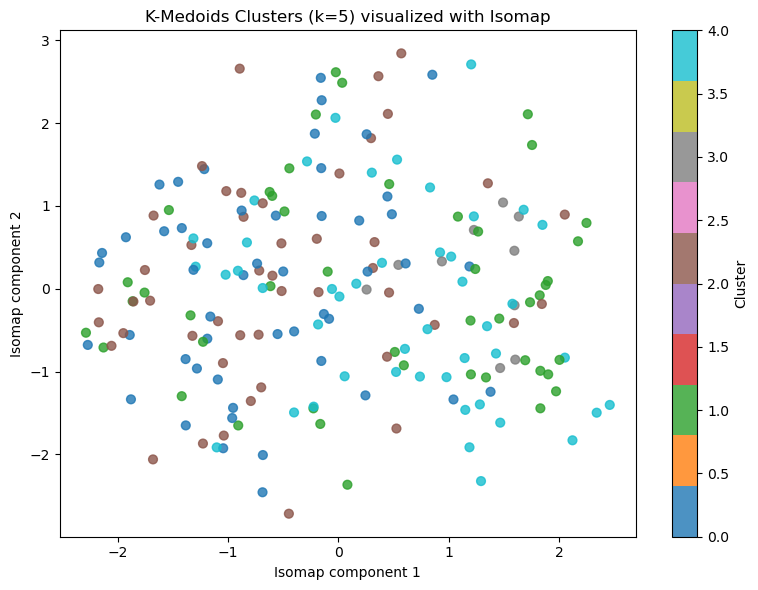

In [6]:
import matplotlib.pyplot as plt
from sklearn.manifold import Isomap

##TODO visualize the k-medoids clustering results through Isomap (first reduce the dimensionality to 2 using Isomap, then use scatter plot (plt.scatter()) to visualize)
isomap = Isomap(n_components=2)
tfidf_2d = isomap.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8, 6))
scatter = plt.scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], c=kmedoids_labels, cmap="tab10", s=40, alpha=0.8)
plt.colorbar(scatter, label="Cluster")
plt.title("K-Medoids Clusters (k=5) visualized with Isomap")
plt.xlabel("Isomap component 1")
plt.ylabel("Isomap component 2")
plt.tight_layout()
plt.show()


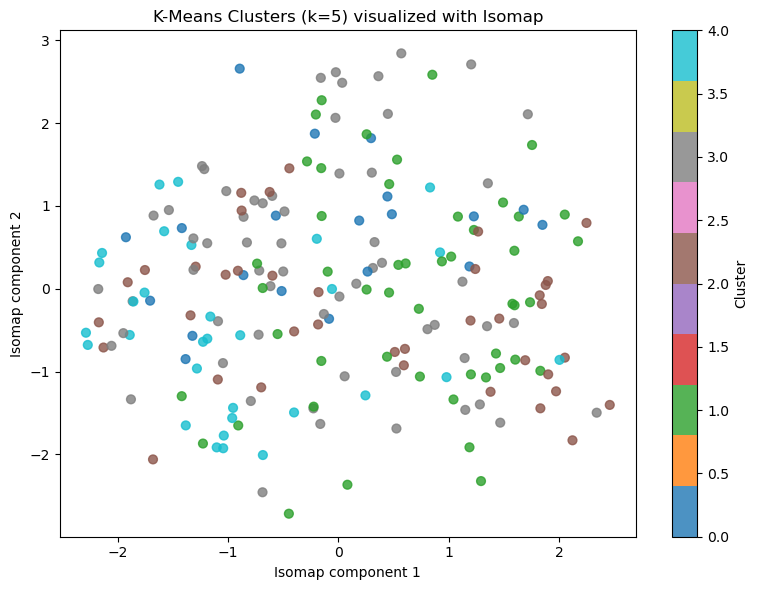

In [7]:
##TODO similarly, visualize the k-means results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tfidf_2d[:, 0], tfidf_2d[:, 1], c=kmeans_labels, cmap="tab10", s=40, alpha=0.8)
plt.colorbar(scatter, label="Cluster")
plt.title("K-Means Clusters (k=5) visualized with Isomap")
plt.xlabel("Isomap component 1")
plt.ylabel("Isomap component 2")
plt.tight_layout()
plt.show()


## Topic Modeling: LDA

For this part you will need to use LDA Mallet. If you cannot have Mallet run, you can use the simple LDA algorithm 

In [8]:
from gensim.corpora import Dictionary
from gensim.models import LdaModel          # LdaMallet wrapper removed in gensim 4.x
from gensim.models.coherencemodel import CoherenceModel

##TODO create a dictionary with the pre-processed tokenized text and filter it according to frequencies and keeping 1000 vocabularies
dictionary = Dictionary(tokenized_docs)
print(f"Dictionary size before filtering: {len(dictionary)}")

dictionary.filter_extremes(no_below=2, no_above=0.8, keep_n=1000)
print(f"Dictionary size after filtering: {len(dictionary)}")

##TODO create the doc_term_matrix
doc_term_matrix = [dictionary.doc2bow(tokens) for tokens in tokenized_docs]
print(f"Corpus: {len(doc_term_matrix)} documents")


Dictionary size before filtering: 2205
Dictionary size after filtering: 678
Corpus: 200 documents


In [19]:
# !wget http://mallet.cs.umass.edu/dist/mallet-2.0.8.zip
# !unzip mallet-2.0.8.zip

In [9]:
##TODO train a LDA Mallet model with 5, 10 and 15 topics
##TODO compute the coherence score for each of these model and print the topics from the model with highest coherence score. Then find the optimal number of topics using the coherence score.

results = {}
for n_topics in [5, 10, 15]:
    model = LdaModel(
        corpus=doc_term_matrix,
        id2word=dictionary,
        num_topics=n_topics,
        random_state=42,
        passes=10,
    )
    coherence = CoherenceModel(
        model=model, texts=tokenized_docs, dictionary=dictionary, coherence="c_v"
    ).get_coherence()
    results[n_topics] = (model, coherence)
    print(f"Topics: {n_topics:2d}  |  Coherence (c_v): {coherence:.4f}")

best_n = max(results, key=lambda k: results[k][1])
best_model = results[best_n][0]
print(f"\nOptimal number of topics: {best_n} (coherence = {results[best_n][1]:.4f})")

print(f"\nTopics from best model (k={best_n}):")
for idx, topic in best_model.print_topics(num_words=10):
    print(f"  Topic {idx}: {topic}")


Topics:  5  |  Coherence (c_v): 0.4583
Topics: 10  |  Coherence (c_v): 0.5044
Topics: 15  |  Coherence (c_v): 0.4853

Optimal number of topics: 10 (coherence = 0.5044)

Topics from best model (k=10):
  Topic 0: 0.036*"ap" + 0.021*"say" + 0.017*"know" + 0.013*"major" + 0.013*"team" + 0.013*"city" + 0.010*"care" + 0.010*"health" + 0.010*"troy" + 0.010*"consensus"
  Topic 1: 0.018*"iraq" + 0.015*"face" + 0.015*"drug" + 0.012*"al" + 0.009*"win" + 0.009*"return" + 0.009*"india" + 0.009*"reuters" + 0.009*"run" + 0.009*"year"
  Topic 2: 0.017*"say" + 0.017*"game" + 0.013*"world" + 0.013*"year" + 0.009*"ap" + 0.009*"new" + 0.009*"bay" + 0.009*"time" + 0.009*"software" + 0.007*"plan"
  Topic 3: 0.017*"world" + 0.014*"end" + 0.014*"oil" + 0.011*"lead" + 0.011*"international" + 0.011*"series" + 0.011*"take" + 0.011*"say" + 0.011*"china" + 0.011*"rate"
  Topic 4: 0.017*"search" + 0.013*"sprint" + 0.013*"ap" + 0.013*"trade" + 0.013*"google" + 0.011*"reuters" + 0.011*"company" + 0.010*"technology" +

In [10]:
#!pip install pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis  # renamed in pyLDAvis 3.3+
# gensim.models.wrappers removed in gensim 4.x — not needed here

##TODO using LDAvis visualize the topics using the optimal number of topics
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(best_model, doc_term_matrix, dictionary, sort_topics=False)
pyLDAvis.display(vis)
